In [3]:
# Advanced Econometrics - Group Assignment 1
# Group 18:
#   Phuc Nguyen, 2779150
#   Tu Nguyen, xxxxxx
#   Boris de Buck, xxxxxx
#   Anna van Dam, xxxxxx

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from scipy import stats
from scipy.optimize import minimize
from scipy.special import gammaln

# Global settings used throughout the assignment
DATA_FILE = 'data/updated_data.csv'
TICKERS = ['PFE', 'JNJ', 'MRK', 'AAPL']
PORTFOLIO = ['PFE', 'JNJ', 'MRK']
T_IN = 2500  # in-sample size for estimation
SEED = 12345
np.random.seed(SEED)
pd.set_option('display.width', 120)

In [4]:
def load_returns(path=DATA_FILE, tickers=TICKERS):
    raw = pd.read_csv(path, usecols=['Ticker', 'DlyCalDt', 'DlyRet'])
    raw = raw.rename(columns={'DlyCalDt': 'Date', 'DlyRet': 'Return'})

    # Reformat the date column and convert the return to percentage
    raw['Date'] = pd.to_datetime(raw['Date'], format='%d/%m/%Y')
    raw['Return'] = pd.to_numeric(raw['Return'], errors='coerce') * 100

    wide = (raw.pivot(index='Date', columns='Ticker', values='Return')
               .sort_index()
               .loc[:, tickers])
    wide.columns.name = None

    if wide.isna().any().any():
        raise ValueError(f'Missing returns found:\n{wide.isna().sum()}')
    return wide


returns = load_returns()
dates = returns.index
T_total = len(returns)
print(f'Sample: {dates[0].date()} to {dates[-1].date()}, {T_total} trading days per stock')
returns.head()

Sample: 2011-01-03 to 2023-12-29, 3270 trading days per stock


,PFE,JNJ,MRK,AAPL
Date,,,,
2011-01-03,0.9709,1.5683,0.0000,2.1732
2011-01-04,1.7449,0.8437,0.8602,0.5219
2011-01-05,0.6754,-0.0631,0.5777,0.8180
2011-01-06,0.3865,-0.1580,1.3676,-0.0808
2011-01-07,0.8801,-0.9650,0.7825,0.7161


In [5]:
# Sanity check against the reference values for AAPL
check = returns['AAPL'].agg(['mean', 'std', 'min', 'max'])
reference = pd.Series({'mean': 0.1071, 'std': 1.7832, 'min': -12.8647, 'max': 11.9808})
assert np.allclose(check.round(4), reference), 'AAPL data does not match the assignment'
print('AAPL check passed:\n', check.round(4).to_string())

# In-sample / out-of-sample split
returns_in = returns.iloc[:T_IN]
split_date = dates[T_IN - 1]                # last in-sample date
print(f'\nIn-sample: {dates[0].date()} to {split_date.date()} ({T_IN} obs); '
      f'out-of-sample: {dates[T_IN].date()} to {dates[-1].date()} ({T_total - T_IN} obs)')

AAPL check passed:
 mean     0.1071
std      1.7832
min    -12.8647
max     11.9808

In-sample: 2011-01-03 to 2020-12-07 (2500 obs); out-of-sample: 2020-12-08 to 2023-12-29 (770 obs)


## Question 2

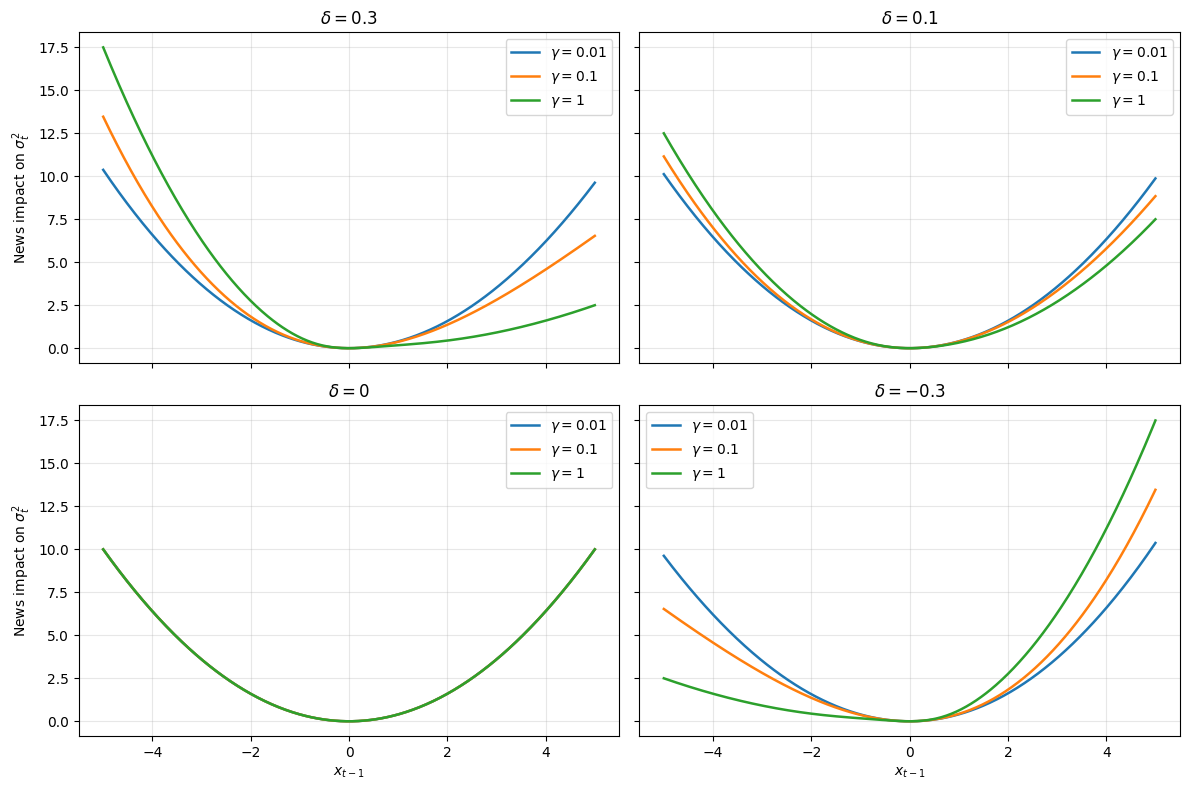

In [8]:
def news_impact_curve(x, alpha, delta=0.0, gamma=0.0, mu=0.0, lbda=0.0, sigma2_prev=1.0):
    """
    News impact curve of the GARCH-M-L model (1): the part of the variance
    recursion that is driven by the lagged return ("the news") x = x_{t-1},
    holding the previous variance fixed at sigma2_prev. The constant terms
    omega and beta*sigma2_prev do not depend on x and are omitted.
    """
    x = np.asarray(x, dtype=float)
    term1 = alpha + delta * np.tanh(-gamma * x)
    term2 = (x - mu - lbda * sigma2_prev) ** 2 / sigma2_prev
    return term1 * term2

# Settings
ALPHA_Q2 = 0.4
DELTAS_Q2 = [0.3, 0.1, 0.0, -0.3]
GAMMAS_Q2 = [0.01, 0.1, 1.0]
x_grid = np.linspace(-5, 5, 500)


def plot_nic_grid(deltas=DELTAS_Q2, gammas=GAMMAS_Q2, alpha=ALPHA_Q2, x=x_grid):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

    for ax, delta in zip(axes.flat, deltas):
        for gamma in gammas:
            ax.plot(x, news_impact_curve(x, alpha, delta, gamma),  lw=1.8,
                    label=rf'$\gamma = {gamma:g}$')
        ax.set_title(rf'$\delta = {delta:g}$')
        ax.grid(alpha=0.3)
        ax.legend()

    for ax in axes[-1, :]:
        ax.set_xlabel(r'$x_{t-1}$')
    for ax in axes[:, 0]:
        ax.set_ylabel(r'News impact on $\sigma_t^2$')
    
    fig.tight_layout()
    plt.show()
    return fig

plot_nic_grid();

## Question 3

In [54]:
# Descriptive statistics
descrp_stats = returns.describe().loc[['count', 'mean', '50%', 'std', 'min', 'max']]
descrp_stats.rename(index={'50%': 'median'}, inplace=True)
descrp_stats.loc['skewness'] = returns.skew()
descrp_stats.loc['excess kurtosis'] = returns.kurtosis()


print(descrp_stats)

# Latex version for the report
descrp_stats.to_latex('descrp_stats.tex', float_format=lambda v: f'{v:.3f}' if abs(v) < 100 else f'{v:.0f}', na_rep='')

                         PFE          JNJ          MRK         AAPL
count            3270.000000  3270.000000  3270.000000  3270.000000
mean                0.040696     0.045667     0.057082     0.107131
median              0.000000     0.036150     0.045900     0.089200
std                 1.368423     1.075906     1.306371     1.783226
min                -7.734600   -10.037900    -9.863000   -12.864700
max                10.855200     7.997700    10.408000    11.980800
skewness            0.223113    -0.149680     0.083055    -0.075740
excess kurtosis     5.294331     9.369579     6.636802     5.360323


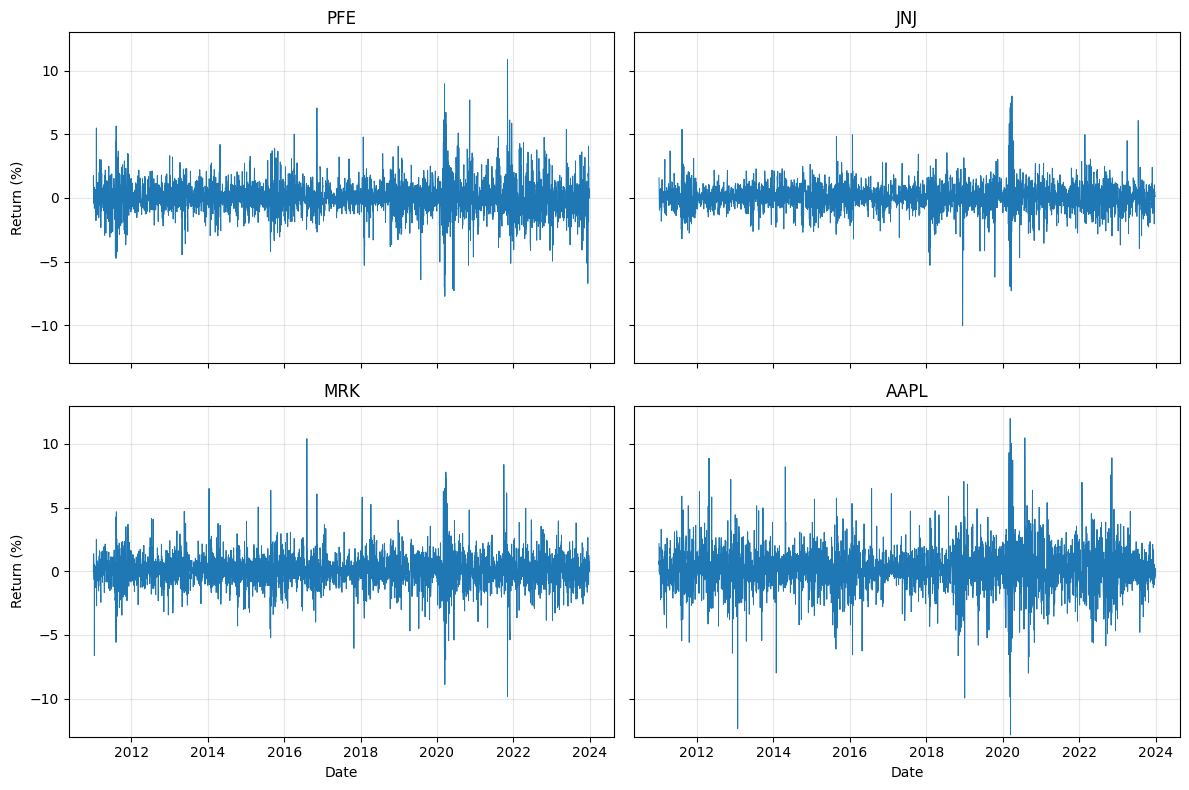

In [7]:
# Plot the four stock returns
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, ticker in zip(axes.flat, TICKERS):
    ax.plot(returns.index, returns[ticker], label=ticker, lw=0.7)
    ax.set_title(f'{ticker}')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ymax = np.ceil(returns.abs().max().max())
axes[0, 0].set_ylim(-ymax, ymax)

for ax in axes[-1, :]:
    ax.set_xlabel('Date')
for ax in axes[:, 0]:
    ax.set_ylabel('Return (%)')

fig.tight_layout()
plt.show()

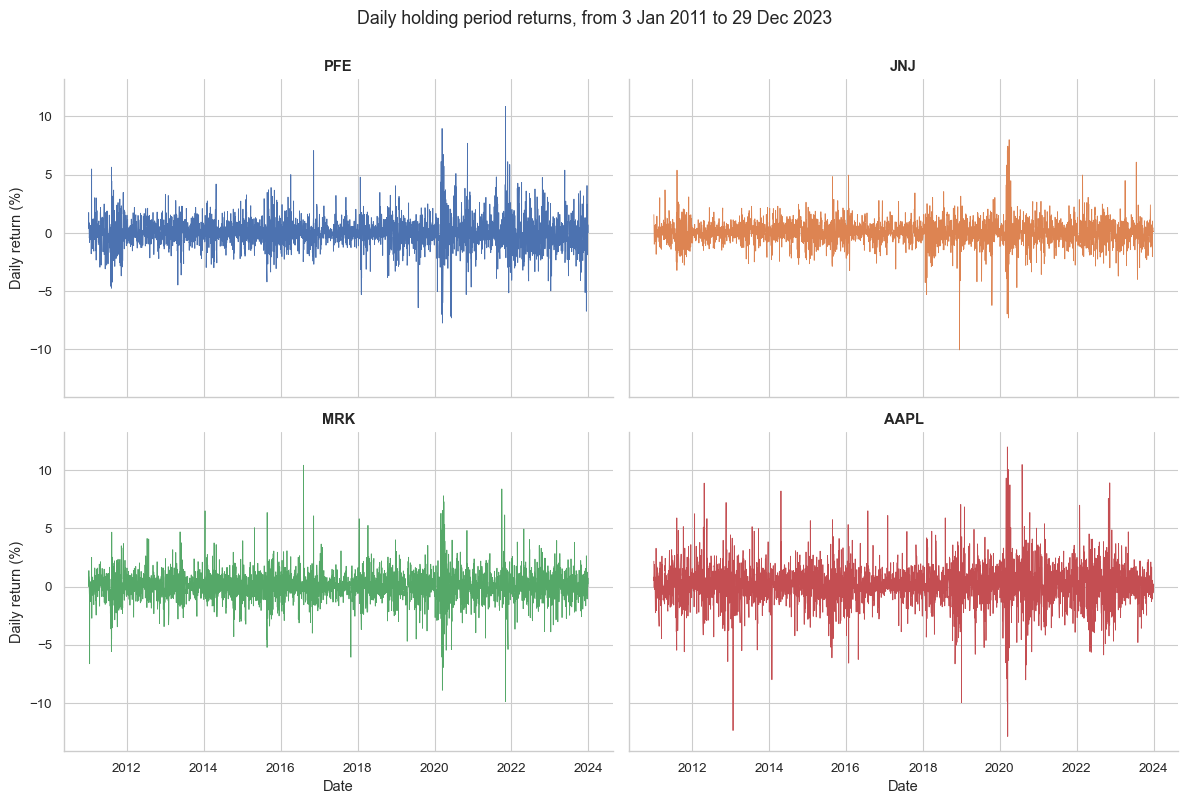

In [ ]:
# OPTIONAL: Use seaborn styling
sns.set_theme(style='whitegrid', context='paper', font_scale=1.1)
palette = dict(zip(TICKERS, sns.color_palette('deep', len(TICKERS))))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, ticker in zip(axes.flat, TICKERS):
    sns.lineplot(x=returns.index, y=returns[ticker], ax=ax, color=palette[ticker], lw=0.6)
    #ax.axhline(0, color='black', lw=0.5)
    ax.set_title(ticker, fontweight='bold')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes[-1, :]:
    ax.set_xlabel('Date')
for ax in axes[:, 0]:
    ax.set_ylabel('Daily return (%)')

fig.suptitle('Daily holding period returns, from 3 Jan 2011 to 29 Dec 2023', y=1.0)
sns.despine(fig)
fig.tight_layout()
plt.show()

sns.reset_defaults()   # do not let the seaborn theme leak into later figures

## Question 4

In [57]:
# Parameter order of the full GARCH-M-L model. The nested models are obtained by
# fixing lbda = 0 (GARCH) and/or delta = gamma = 0 (GARCH, GARCH-M).
PARAM_NAMES = ['mu', 'lbda', 'omega', 'alpha', 'beta', 'delta', 'gamma', 'nu']


def garch_ml_filter(x, mu, lbda, omega, alpha, beta, delta=0.0, gamma=0.0, sigma2_init=None):
    x = np.asarray(x)
    T = len(x)
    sigma2 = np.empty(T)
    sigma2[0] = np.var(x[:50]) if sigma2_init is None else sigma2_init

    for t in range(1, T):
        eps2_prev = (x[t-1] - mu - lbda * sigma2[t-1]) ** 2 / sigma2[t-1]
        sigma2[t] = omega + (alpha + delta * np.tanh(-gamma * x[t-1])) * eps2_prev + beta * sigma2[t-1]
        if not sigma2[t] > 0:
            sigma2[t:] = np.nan
            break
    return sigma2


def student_t_loglik(x, sigma2, mu, lbda, nu):
    """
    Log-density contributions log p(x_t | F_{t-1}) for x_t = mu + lbda*sigma2_t + sigma_t*eps_t,
    eps_t ~ t(nu). By the change-of-variables theorem:
        log p(x_t | F_{t-1}) = log f_t((x_t - mu - lbda*sigma2_t)/sigma_t; nu) - 0.5*log(sigma2_t),
    with the Student-t log-pdf written out explicitly using the stable log-gamma function.
    """
    eps2 = (x - mu - lbda * sigma2) ** 2 / sigma2
    const_term = gammaln((nu + 1) / 2) - gammaln(nu / 2) - 0.5 * np.log(nu * np.pi)
    loglik = const_term - 0.5 * (nu + 1) * np.log1p(eps2 / nu) - 0.5 * np.log(sigma2)
    return loglik


def total_loglik(x, mu, lbda, omega, alpha, beta, delta=0.0, gamma=0.0, nu=10.0):
    """Total log-likelihood L_T of the (nested) GARCH-M-L model for the sample x."""
    x = np.asarray(x, dtype=float)
    sigma2 = garch_ml_filter(x, mu, lbda, omega, alpha, beta, delta, gamma)
    if np.isnan(sigma2).any() or nu <= 2:
        return -np.inf
    return student_t_loglik(x, sigma2, mu, lbda, nu).sum()

In [58]:
# Check against AAPL results
x_aapl = returns_in['AAPL'].values
reference_aapl = {
    'GARCH':     dict(mu=0.154, lbda=0.000, omega=0.038, alpha=0.090, beta=0.873, nu=4.146),
    'GARCH-M':   dict(mu=0.072, lbda=0.061, omega=0.037, alpha=0.089, beta=0.875, nu=4.138),
    'GARCH-M-L': dict(mu=0.108, lbda=0.022, omega=0.012, alpha=0.073, beta=0.915,
                      delta=0.071, gamma=0.439, nu=4.402),
}
for name, p in reference_aapl.items():
    print(f'{name:10s} log-likelihood value at reference estimates: {total_loglik(x_aapl, **p):10.2f}')

GARCH      log-likelihood value at reference estimates:   -4662.49
GARCH-M    log-likelihood value at reference estimates:   -4661.55
GARCH-M-L  log-likelihood value at reference estimates:   -4632.21


In [59]:
MODELS = {
    'GARCH':     ['mu', 'omega', 'alpha', 'beta', 'nu'],
    'GARCH-M':   ['mu', 'lbda', 'omega', 'alpha', 'beta', 'nu'],
    'GARCH-M-L': ['mu', 'lbda', 'omega', 'alpha', 'beta', 'delta', 'gamma', 'nu'],
}
GAMMA_PENALTY = 0.001
# eps = finite-difference step for the numerical gradient. The default (1.5e-8) is too small
# for a likelihood built from a 2,500-step recursion: round-off noise dominates the gradient
# and BFGS quits with "precision loss" even though it is at the optimum.
BFGS_OPTIONS = {'maxiter': 5000, 'gtol': 1e-4, 'eps': 1e-6}
NM_OPTIONS = {'maxiter': 20000, 'maxfev': 40000, 'xatol': 1e-7, 'fatol': 1e-9, 'adaptive': True}

def starting_values(x, model):
    s2 = np.var(x)
    start = dict(mu=0.0, lbda=0.0, omega=s2/50, alpha=0.05, beta=0.9, delta=0.01, gamma=0.01, nu=10.0)
    return np.array([start[name] for name in MODELS[model]])

def unpack(theta, model):
    params = dict.fromkeys(PARAM_NAMES, 0.0)
    params.update(zip(MODELS[model], theta))
    return params

def neg_penalized_loglik(theta, x, model):
    p = unpack(theta, model)
    loglik = total_loglik(x, **p)
    if not np.isfinite(loglik):
        return 1e10
    return -loglik + GAMMA_PENALTY * p['gamma'] ** 2 

def estimate_model(x, model, tol=1e-4):
    """
    Maximum likelihood estimation of one model on the sample x.

    Step 1: BFGS from the starting values (fast, gradient based).
    Step 2: Nelder-Mead polish from the BFGS solution (derivative free, so immune to
            the numerical-gradient noise that makes BFGS report "precision loss").
    The estimate is declared converged if BFGS itself converged, or if Nelder-Mead
    converged and could not improve the BFGS objective by more than `tol`, i.e. the
    BFGS point was already the optimum.
    Returns a dict with parameters, log-likelihood, AIC, BIC and convergence info.
    """
    x = np.asarray(x, dtype=float)
    T = len(x)
    theta0 = starting_values(x, model)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        bfgs = minimize(neg_penalized_loglik, theta0, args=(x, model), method='BFGS', options=BFGS_OPTIONS)
        nm = minimize(neg_penalized_loglik, bfgs.x, args=(x, model), method='Nelder-Mead', options=NM_OPTIONS)

    res = nm if nm.fun <= bfgs.fun else bfgs           # keep the better of the two
    improvement = bfgs.fun - nm.fun                    # gain from polishing (should be ~0)
    converged = bool(bfgs.success or (nm.success and abs(improvement) < tol))

    params = unpack(res.x, model)
    loglik = total_loglik(x, **params)                 # unpenalised log-likelihood at the optimum
    k = len(res.x)
    aic = 2 * k - 2 * loglik
    bic = k * np.log(T) - 2 * loglik
    return dict(model=model, params=params, loglik=loglik, k=k, T=T, AIC=aic, BIC=bic,
                converged=converged, bfgs_success=bool(bfgs.success), nm_success=bool(nm.success),
                improvement=improvement, message=res.message)


# Estimate all three models for all four stocks on the first T_IN observations
estimates = {}
for ticker in TICKERS:
    x_in = returns_in[ticker].values
    for model in MODELS:
        est = estimate_model(x_in, model)
        estimates[(ticker, model)] = est
        print(f"{ticker:5s} {model:10s} log-lik = {est['loglik']:9.2f}   converged = {est['converged']!s:5s} "
              f"(BFGS {est['bfgs_success']!s:5s} | NM {est['nm_success']!s:5s})")

not_converged = [key for key, est in estimates.items() if not est['converged']]
print('\nAll estimations converged.' if not not_converged else f'\nWARNING, not converged: {not_converged}')

PFE   GARCH      log-lik =  -3769.41   converged = True  (BFGS False | NM True )
PFE   GARCH-M    log-lik =  -3766.90   converged = True  (BFGS False | NM True )
PFE   GARCH-M-L  log-lik =  -3753.11   converged = True  (BFGS True  | NM True )
JNJ   GARCH      log-lik =  -3282.81   converged = True  (BFGS False | NM True )
JNJ   GARCH-M    log-lik =  -3282.71   converged = True  (BFGS False | NM True )
JNJ   GARCH-M-L  log-lik =  -3270.35   converged = True  (BFGS False | NM True )
MRK   GARCH      log-lik =  -3892.92   converged = True  (BFGS False | NM True )
MRK   GARCH-M    log-lik =  -3892.89   converged = True  (BFGS True  | NM True )
MRK   GARCH-M-L  log-lik =  -3868.25   converged = True  (BFGS True  | NM True )
AAPL  GARCH      log-lik =  -4662.48   converged = True  (BFGS False | NM True )
AAPL  GARCH-M    log-lik =  -4661.55   converged = True  (BFGS True  | NM True )
AAPL  GARCH-M-L  log-lik =  -4632.19   converged = True  (BFGS True  | NM True )

All estimations converged.


In [60]:
def estimates_table(estimates, tickers=TICKERS, models=tuple(MODELS)):
    row_labels = {'mu': 'μ', 'lbda': 'λ', 'omega': 'ω', 'alpha': 'α', 'beta': 'β',
                  'delta': 'δ', 'gamma': 'γ', 'nu': 'ν'}
    columns = {}
    for ticker in tickers:
        for model in models:
            est = estimates[(ticker, model)]
            col = {row_labels[p]: (est['params'][p] if p in MODELS[model] else np.nan)
                   for p in PARAM_NAMES}
            col.update({'Log-lik': est['loglik'], 'AIC': est['AIC'], 'BIC': est['BIC']})
            columns[(ticker, model)] = col
    table = pd.DataFrame(columns)
    table.columns = pd.MultiIndex.from_tuples(table.columns, names=['Stock', 'Model'])
    return table

q4_table = estimates_table(estimates).round(3)
fmt = lambda v: f'{v:.3f}' if abs(v) < 100 else f'{v:.0f}'
print(q4_table.to_string(float_format=fmt, na_rep=''))

# LaTeX version for the report
q4_table.to_latex('table_q4_estimates.tex', float_format=fmt, na_rep='', multicolumn=True)

Stock      PFE                      JNJ                     MRK                    AAPL                  
Model    GARCH GARCH-M GARCH-M-L  GARCH GARCH-M GARCH-M-L GARCH GARCH-M GARCH-M-L GARCH GARCH-M GARCH-M-L
μ        0.037  -0.028    -0.031  0.072   0.058     0.033 0.066   0.077    -0.046 0.154   0.072     0.108
λ                0.111     0.104          0.031     0.063        -0.015     0.117         0.061     0.022
ω       -0.027  -0.028    -0.025 -0.002  -0.002     0.003 0.014   0.015     0.019 0.038   0.037     0.012
α        0.036   0.036     0.043  0.025   0.025     0.026 0.039   0.040     0.040 0.090   0.089     0.073
β        0.961   0.963     0.953  0.923   0.924     0.916 0.906   0.904     0.906 0.874   0.875     0.915
δ                          0.029                    0.017                   0.039                   0.071
γ                          0.410                    1.228                   4.742                   0.439
ν        4.651   4.677     4.903  4.394   4.38